# Generate a voltage-time + spectrogram from a given velocity time history

### Input velocity vs time curve

In [176]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import ShortTimeFFT
from matplotlib.patches import Rectangle

def stft(voltage, fs, window, nperseg, noverlap, nfft):
    # calculate stft with the new scipy library function and zero padding the boundaries
    SFT = ShortTimeFFT.from_window(
        window,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        mfft=nfft,
        scale_to="magnitude",
        phase_shift=None,
    )
    Sx_full = SFT.stft(voltage, padding="zeros")
    t_full = SFT.t(len(voltage))
    f = SFT.f

    # calculate the time array for the legacy scipy stft function without zero padding on the boundaries
    t_legacy = np.arange(
        nperseg / 2,
        voltage.shape[-1] - nperseg / 2 + 1,
        nperseg - noverlap,
    ) / float(fs)

    # find the time index in the new stft function that corresponds to where the legacy function time array begins
    t_idx = np.argmin(np.abs(t_full - t_legacy[0]))

    # crop the time array to the length of the legacy function
    t_crop = t_full[t_idx : t_idx + len(t_legacy)]

    # crop the stft magnitude array to the length of the legacy function
    Sx_crop = Sx_full[:, t_idx : t_idx + len(t_legacy)]

    # return the frequency, time, and magnitude arrays
    return f, t_crop, Sx_crop

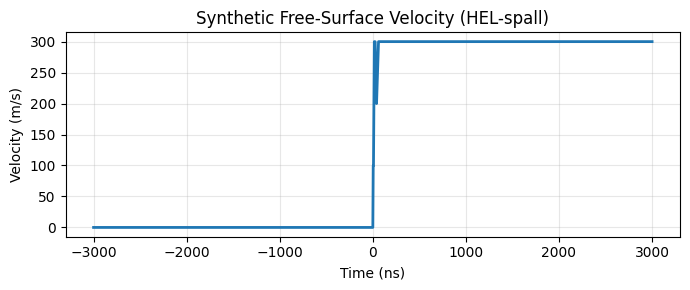

In [177]:
# Sampling and constants
sample_rate = 128e9  # Hz
lambda_ref = 1550e-9  # m
lambda_tar = 1550.016e-9
noise_sd = 0.1
c=3e8

# Choose the shot type: "velocity", "HEL", "spall", "HEL-spall"
shot_type = "HEL-spall"

# Define simple linear segments
if shot_type == "velocity":
    t_end = 1000e-9 #s
    t_begin = -500e-9 #s
    vel_peak = 200 #m/s
    time = np.arange(t_begin,t_end,1/sample_rate)
    a = 1 #function smoothing parameter
    b = 0.00001 #function shifting parameter
    intercept = b/vel_peak/a
    x = (time>0)*time
    vel_sim = (vel_peak*(x+intercept)*a-b)/(x+intercept)*a
elif shot_type == "HEL":
    t_begin, t_end = -3e-6, 3e-6
    V0, V_HEL, V_plat = 0, 50, 300
    t_rise1, t_rise2, t_rise3 = 20e-9, 30e-9, 50e-9
    time = np.arange(t_begin, t_end, 1/sample_rate)
    vel_sim = np.zeros_like(time)
    for i, t in enumerate(time):
        if t < 0:
            vel_sim[i] = V0
        elif t < t_rise1:
            vel_sim[i] = V0 + (V_HEL - V0) * (t / t_rise1)
        elif t < t_rise2:
            vel_sim[i] = V0 + V_HEL
        elif t < t_rise3:
            vel_sim[i] = V_HEL + (V_plat - V_HEL) * ((t-t_rise2) / (t_rise3-t_rise2))
        else:
            vel_sim[i] = V_plat

elif shot_type == "HEL-spall":
    # Piecewise linear HEL + plateau + spall pullback + recovery
    t_begin, t_end = -3e-6, 3e-6
    V0, V_HEL, V_plat = 0, 100, 300
    t_hel_start, t_hel_end = 3e-9, 7e-9
    t_plat_start, t_plat_end = 15e-9, 25e-9
    t_spall = 40e-9
    t_recover = 60e-9
    dV_spall = 100
    time = np.arange(t_begin, t_end, 1/sample_rate)
    vel_sim = np.zeros_like(time)
    for i, t in enumerate(time):
        if t < 0:
            vel_sim[i] = V0
        elif t < t_hel_start:
            vel_sim[i] = V0 + (V_HEL - V0) * (t / t_hel_start)
        elif t < t_hel_end:
            vel_sim[i] = V_HEL
        elif t < t_plat_start:
            vel_sim[i] = V_HEL + (V_plat - V_HEL) * (t - t_hel_end) / (t_plat_start - t_hel_end)
        elif t < t_plat_end:
            vel_sim[i] = V_plat
        elif t < t_spall:
            vel_sim[i] = V_plat - dV_spall * (t - t_plat_end) / (t_spall - t_plat_end)
        elif t < t_recover:
            vel_sim[i] = V_plat - dV_spall + dV_spall * (t - t_spall) / (t_recover - t_spall)
        else:
            vel_sim[i] = V_plat

else:
    raise ValueError("Invalid shot_type")

# Plot result
plt.figure(figsize=(7,3))
plt.plot(time*1e9, vel_sim, lw=2)
plt.xlabel("Time (ns)")
plt.ylabel("Velocity (m/s)")
plt.title(f"Synthetic Free-Surface Velocity ({shot_type})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Convert into position to get phase difference
- This is wrt the target laser (would be the phase difference for a homodyne system)

$$
\phi(t) = \frac{4 \pi \Delta L(t) \,}{\lambda}
$$

- Calculate the difference in phi by setting L_0 to equal 0. The position therefore equals L

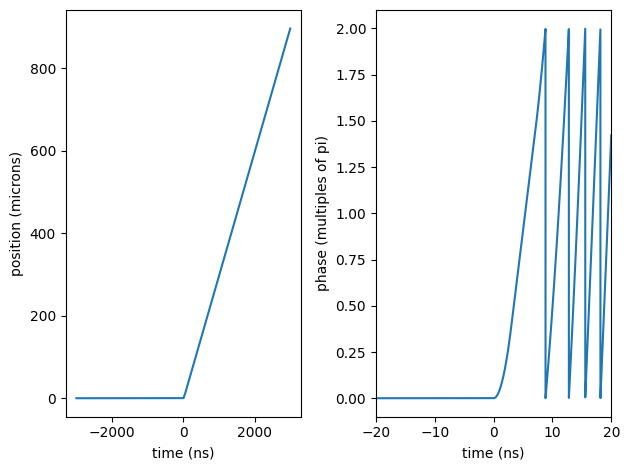

In [178]:
pos_sim = np.cumsum(vel_sim/sample_rate)
fig, ax = plt.subplots(1,2)
ax[0].plot(time*1e9,pos_sim*1e6)
ax[0].set_xlabel("time (ns)")
ax[0].set_ylabel("position (microns)")

phase = 4*np.pi*pos_sim/lambda_ref

#wrap the phase
phase_wrapped = np.remainder(phase,2*np.pi)
ax[1].plot(time*1e9,phase_wrapped/np.pi)
ax[1].set_ylabel("phase (multiples of pi)")
ax[1].set_xlabel("time (ns)")
ax[1].set_xlim([-20,20])

fig.tight_layout()

### Optical Field Definitions in Heterodyne PDV (single point)


#### **Laser Source Field**

$$
E_{tar} = E_{tar0} \cos(2\pi f_L t)
$$

This represents the **original laser field** emitted at optical frequency
$$
f_L = \frac{c}{\lambda}
$$
It is the laser field of the target before it is reflected off a moving surface. 

#### **Local Oscillator / Reference Field**

$$
E_{ref} = E_{ref0} \cos[2\pi (f_L + f_0)t]
$$

This is the **reference (local oscillator)** beam.  
It is derived from $ E_r $ and **frequency-shifted by $ f_0 $** (e.g., 2 GHz).  
It provides a **stable, known phase** for heterodyne mixing at the detector.


#### **Reflected (Signal) Field from the Moving Surface**

$$
E_s = E_{s0} \cos\!\left[2\pi f_L t - \frac{4\pi L(t)}{\lambda}\right]
$$

This is **signal** or **reflected beam** returning from the moving target surface.  
The term $ \frac{4\pi L(t)}{\lambda} $ represents the **round-trip phase shift** due to motion;  
its time derivative encodes the **Doppler velocity** of the surface.

#### **Combined Field at the Detector**

$$
E_{\text{total}} = E_{ref} + E_s
$$

The detector measures **intensity**, proportional to $ |E_{\text{total}}|^2 $,  
producing a **beat signal** at frequency $ f_0 \pm f_D $,  
where $ f_D = \frac{2v}{\lambda} $ is the Doppler shift from target motion.

---

#### **Detected Intensity (Beat Signal)**

$$
I(t) \propto E_{ref0}^2 + E_{s0}^2 + 2E_{ref0}E_{s0} 
\cos\!\left[2\pi f_0 t - \frac{4\pi L(t)}{\lambda}\right]
$$

The **cross term** contains the **heterodyne beat**.  
Its phase $ 2\pi f_0 t - \frac{4\pi L(t)}{\lambda} $ evolves with target displacement.  
The squared terms are DC signals automatically filtered out by oscilloscope

$$
I(t) \propto 2E_{ref0}E_{s0} 
\cos\!\left[2\pi f_0 t - \frac{4\pi L(t)}{\lambda}\right]
$$

---

#### **Constant Reflection Case**

$$
E_{\text{total}} = E_{ref} + E_s + E_{tar}
$$

Where $E_{tar}$ is the electromagnetic field of the original outgoing source field. This is the result of a backreflection off a stationary target. 

The same logic may be applied here: 

$$
I(t) \propto 2E_{ref0}E_{s0} + 2E_{ref0}E_{tar0} + 2E_{tar0}E_{s0}
$$




(0.0, 10.0)

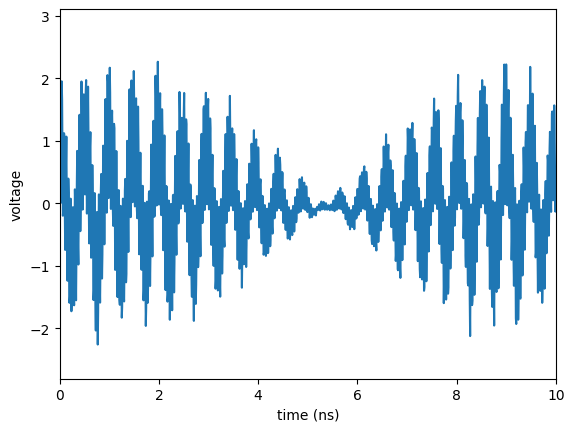

In [179]:
f_tar = c/lambda_tar
f_ref = c/lambda_ref

# Laser Powers
power_ref = 1 #dbm
power_s = -1 #dbm (power target return or signal)
power_tar = power_s  #dbm (power target output) (reflected)

E_ref0 = 10**(power_ref/2)
E_tar0 = 10**(power_tar/2)
E_s0 = 10**(power_s/2)

E_tar = E_tar0 * np.cos(2*np.pi*f_tar*time)
E_ref = E_ref0 * np.cos(2*np.pi*f_ref*time)
E_s = E_s0 * np.cos(2*np.pi*f_tar*time-phase)


voltage = E_ref*E_s + E_ref*E_tar + E_tar*E_s

# Add in noise
voltage = voltage * (1 + np.random.normal(0,noise_sd,voltage.shape[0]))

plt.plot(time*1E9,voltage)
plt.xlabel("time (ns)")
plt.ylabel("voltage")
plt.xlim([0,10])

### Generate Spectrogram

Text(0.5, 1.0, 'Spectrogram Original Signal')

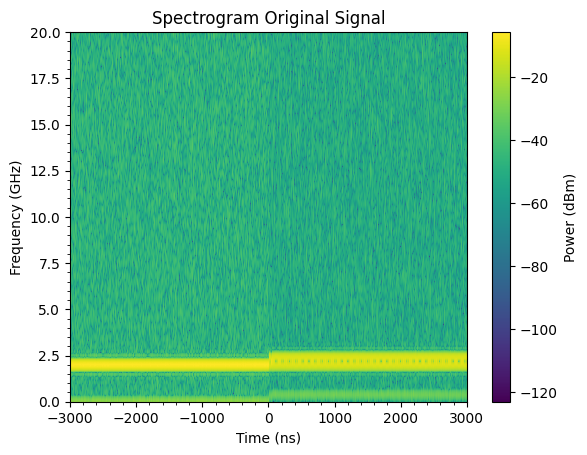

In [180]:
# sampling frequency in Hz (sample_rate is already in samples/sec)
fs = sample_rate
nperseg = 600
noverlap = 500
nfft = 5120
window = "hann"

f, t, Zxx = stft(voltage, fs, window, nperseg, noverlap, nfft)

mag = np.abs(Zxx)

# imported voltage spectrogram and a rectangle to show the ROI
plt.imshow(
    10 * np.log10(mag ** 2),
    aspect="auto",
    origin="lower",
    interpolation="none",
    extent=[
        t_begin / 1e-9,
        t_end / 1e-9,
        f[0] / 1e9,
        f[-1] / 1e9,
    ],
    cmap="viridis",
)

plt.colorbar(label="Power (dBm)")
plt.ylim([0,20])
plt.xlabel("Time (ns)")
plt.ylabel("Frequency (GHz)")
plt.minorticks_on()
plt.title("Spectrogram Original Signal")

In [181]:
x = time
y = voltage

output_file = "waveform.csv"

with open(output_file, "w", newline="") as f:
    # ---- Data ----
    for xi, yi in zip(x, y):
        f.write(f"{xi:.9E},{yi:.7E}\n")

# Multipoint
- Same idea as before, but mixing for multiple frequencies
- There is no beat frequencies (or crosstalk) created between probes due to large spacing (eg 1531nm to 1537nm)

(0.0, 20.0)

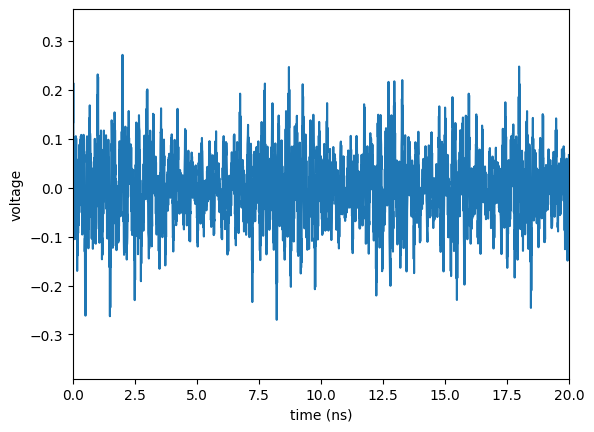

In [182]:
points = 2
# ref_freq = c/(np.array([1531.116,1537.397,1543.730,1550.116])*1e-9)
ref_lambda = np.array([1531.116,1537.397,1543.730])*1e-9
ref_freq = c/ref_lambda
tar_freq = ref_freq - np.array([3,7,10]) * 1e9 #Hz


power_ref = 8 #dbm
power_s = -10 #dbm (power target return or signal)
power_tar = power_s - 1 #dbm (power target output)
E_ref0 = 10**(power_ref/2)
E_tar0 = 10**(power_tar/2)
E_s0 = 10**(power_s/2)

voltage_multi = np.zeros(time.shape[0])

for i in range(points):
        # calculate phase change in return 
        pos_sim = np.cumsum(vel_sim/sample_rate)
        phase = 4*np.pi*pos_sim/ref_lambda[i]

        #wrap the phase
        phase_wrapped = np.remainder(phase,2*np.pi)

        f_ref = ref_freq[i]
        f_tar = tar_freq[i]

        E_ref = E_ref0 * np.cos(2*np.pi*f_ref*time) #Reference Signal
        E_s = E_s0 * np.cos(2*np.pi*f_tar*time - phase_wrapped) #Doppler Shifted Signal
        E_tar = E_tar0 * np.cos(2*np.pi*f_tar*time) # Target Signal (Constant Reflection)

        voltage_multi = voltage_multi + E_ref * E_s + E_ref * E_tar + E_s * E_tar

voltage_multi = voltage_multi * (1+np.random.normal(0,noise_sd,voltage.shape[0]))

plt.plot(time*1E9,voltage_multi)
plt.xlabel("time (ns)")
plt.ylabel("voltage")
plt.xlim([0,20])

Text(0.5, 1.0, 'Spectrogram Original Signal')

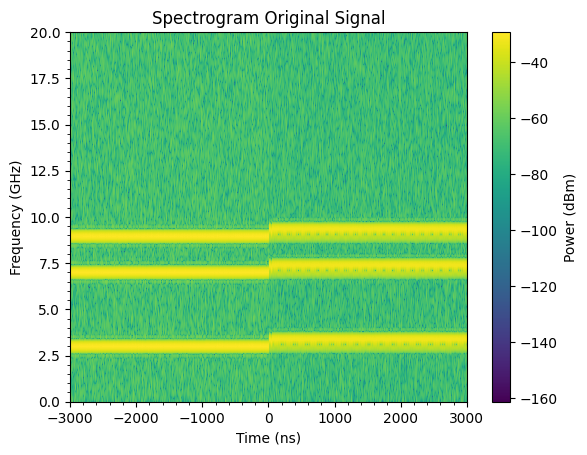

In [183]:
# sampling frequency in Hz (sample_rate is already in samples/sec)
fs = sample_rate
nperseg = 600
noverlap = 500
nfft = 5120
window = "hann"

f, t, Zxx = stft(voltage_multi, fs, window, nperseg, noverlap, nfft)

mag = np.abs(Zxx)

# imported voltage spectrogram and a rectangle to show the ROI
plt.imshow(
    10 * np.log10(mag ** 2),
    aspect="auto",
    origin="lower",
    interpolation="none",
    extent=[
        t_begin / 1e-9,
        t_end / 1e-9,
        f[0] / 1e9,
        f[-1] / 1e9,
    ],
    cmap="viridis",
)

plt.colorbar(label="Power (dBm)")
plt.ylim([0,20])
plt.xlabel("Time (ns)")
plt.ylabel("Frequency (GHz)")
plt.minorticks_on()
plt.title("Spectrogram Original Signal")

In [184]:
x = time
y = voltage_multi

output_file = "waveform_multi.csv"

with open(output_file, "w", newline="") as f:
    # ---- Data ----
    for xi, yi in zip(x, y):
        f.write(f"{xi:.9E},{yi:.7E}\n")
